# Task 1 — Audio Clustering

**This notebook is the single entry point for Task 1.**

- **Section 0** — trigger the pipeline and watch live progress  
- **Section 1** — explore the feature space (distributions, correlations)  
- **Section 2** — k selection across markets  
- **Section 3** — UMAP scatter (pick any country)  
- **Section 4** — same track across different markets  
- **Section 5** — cluster profiles (what does each cluster sound like?)  
- **Section 6** — sample tracks per cluster

The API handles the computation; this notebook drives and explains it.

In [17]:
import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
from db import engine

plt.style.use('dark_background')
GREEN = '#1db954'
API   = 'http://localhost:8000'

FEATURES = [
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature',
]

try:
    h = requests.get(f'{API}/health', timeout=3).json()
    print(f"API {h['status']}  ·  DB {h['db']}")
except Exception as e:
    print(f'API unreachable: {e} — make sure `just up` is running.')

API ok  ·  DB connected


---
## 0. Run the clustering

Triggers the per-country K-Means pipeline and streams live progress until done.  
Re-running is safe — `ON CONFLICT DO UPDATE`.

> Set `INCLUDE_GLOBAL = True` to also compute a cross-market reference pass (`country='GL'`).

In [18]:
INCLUDE_GLOBAL = False

def _bar(done, total, width=28):
    pct  = done / total if total else 0
    fill = int(pct * width)
    return f"[{'█' * fill}{'░' * (width - fill)}] {done}/{total} ({pct:.0%})"

def run_clustering(include_global=False):
    s = requests.get(f'{API}/clustering/audio/status', timeout=5).json()
    if s['running']:
        print('Already running — attaching to existing job ...')
    else:
        r = requests.post(
            f'{API}/clustering/audio',
            params={'include_global': str(include_global).lower()},
            timeout=5,
        )
        r.raise_for_status()
        print(r.json()['message'])

    while True:
        s = requests.get(f'{API}/clustering/audio/status', timeout=5).json()
        clear_output(wait=True)
        print(f"  stage          : {s['stage']}")
        print(f"  country        : {s['country_current'] or '—'}")
        print(f"  countries      : {_bar(s['countries_done'], s['countries_total'])}")
        if s['countries_skipped']:
            print(f"  skipped        : {s['countries_skipped']} (< 30 unique tracks)")
        print(f"  k (sweep)      : {s['k_current'] or '—'}")
        print(f"  k (best)       : {s['k_best_this'] or '—'}")
        print(f"  rows written   : {s['tracks_persisted']:,}")
        if s.get('last_error'):
            print(f"  error          : {s['last_error']}")
        if not s['running']:
            print('\nDone.' if s['stage'] == 'done' else '\nError — see above.')
            break
        time.sleep(4)

run_clustering(include_global=INCLUDE_GLOBAL)

  stage          : done
  country        : ZA
  countries      : [████████████████████████████] 72/72 (100%)
  k (sweep)      : 15
  k (best)       : 14
  rows written   : 53,760

Done.


---
## 1. Feature space

| Feature | Range | Meaning |
|---|---|---|
| `danceability` | 0–1 | Suitability for dancing |
| `energy` | 0–1 | Perceived intensity |
| `key` | 0–11 | Pitch class (C=0 … B=11) |
| `loudness` | dBFS | Overall loudness |
| `mode` | 0/1 | Minor=0, Major=1 |
| `speechiness` | 0–1 | Spoken words present |
| `acousticness` | 0–1 | Acoustic confidence |
| `instrumentalness` | 0–1 | No vocals predicted |
| `liveness` | 0–1 | Audience in recording |
| `valence` | 0–1 | Musical positiveness |
| `tempo` | BPM | Estimated tempo |
| `time_signature` | 3–7 | Beats per bar |

In [19]:
feat_sql = ', '.join(f'AVG({f})::float4 AS {f}' for f in FEATURES)
not_null = ' AND '.join(f'AVG({f}) IS NOT NULL' for f in FEATURES)
df_all   = pd.read_sql(f"""
    SELECT spotify_id, {feat_sql}
    FROM   tracks
    GROUP  BY spotify_id
    HAVING {not_null}
""", engine)
print(f'{len(df_all):,} unique tracks with complete audio features')
df_all[FEATURES].describe().round(3)

24,979 unique tracks with complete audio features


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,24979.000,24979.000,24979.000,24979.000,24979.000,24979.000,24979.000,24979.000,24979.000,24979.000,24979.000,24979.000
mean,0.673,0.654,5.369,-7.013,0.513,0.121,0.273,0.027,0.184,0.533,122.452,3.947
std,0.140,0.170,3.608,3.109,0.500,0.113,0.250,0.127,0.139,0.229,27.795,0.350
min,0.000,0.002,0.000,-54.341,0.000,0.000,0.000,0.000,0.014,0.000,0.000,0.000
25%,0.584,0.548,2.000,-8.289,0.000,0.042,0.063,0.000,0.098,0.357,99.990,4.000
50%,0.691,0.671,6.000,-6.527,1.000,0.070,0.195,0.000,0.128,0.533,121.393,4.000
75%,0.775,0.778,9.000,-5.109,1.000,0.165,0.429,0.000,0.227,0.710,140.032,4.000
max,0.988,0.998,11.000,3.132,1.000,0.957,0.996,0.995,0.983,0.992,236.089,5.000


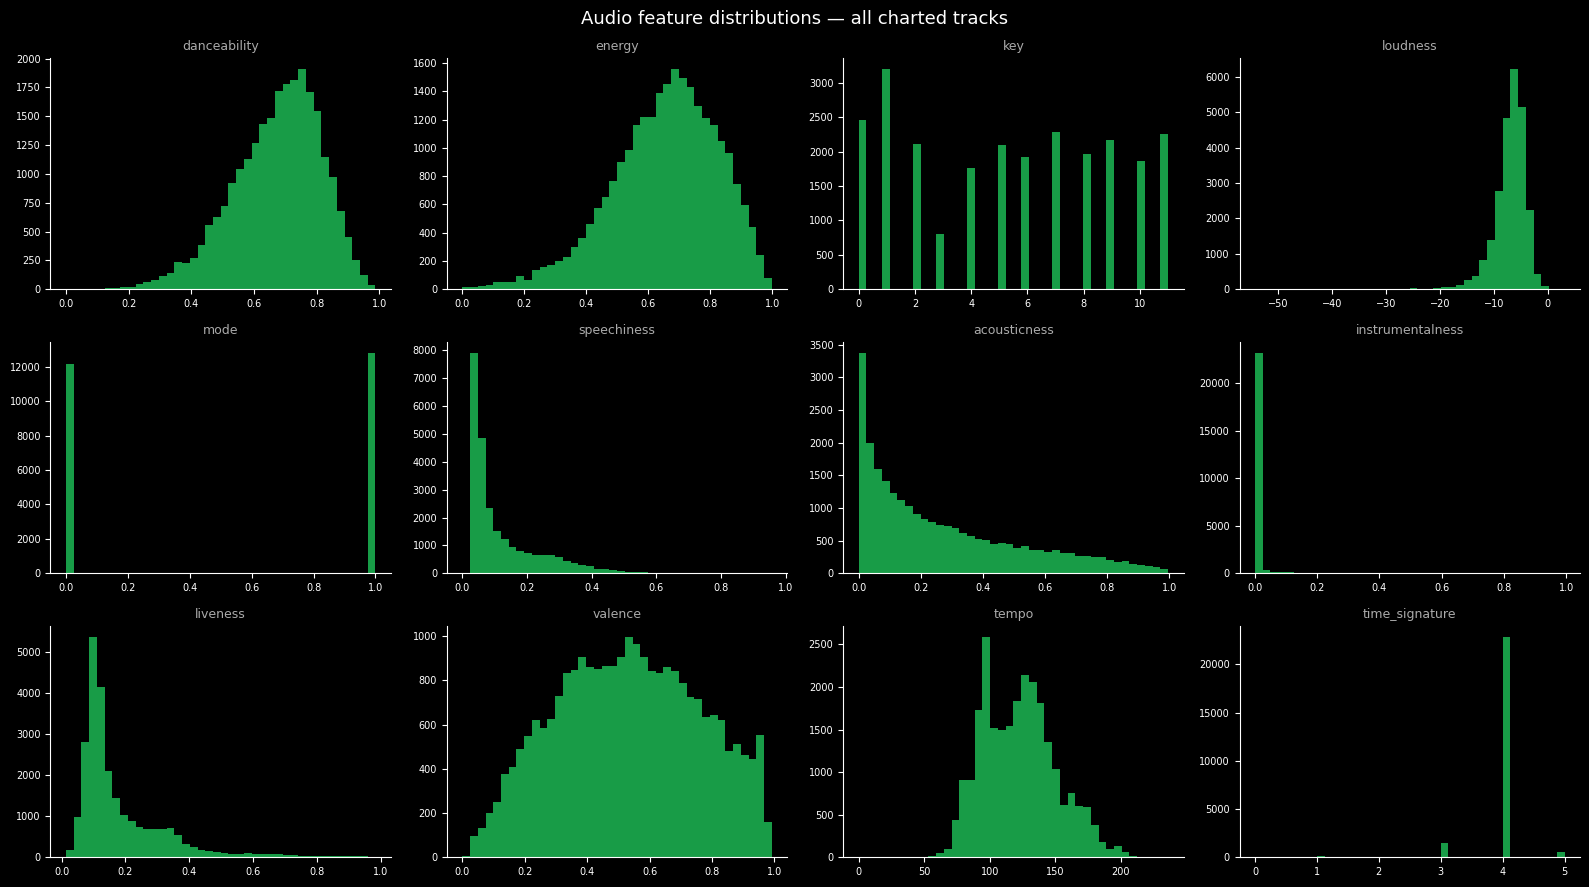

In [20]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
fig.suptitle('Audio feature distributions — all charted tracks', color='white', fontsize=13)
for ax, feat in zip(axes.flat, FEATURES):
    ax.hist(df_all[feat].dropna(), bins=40, color=GREEN, alpha=0.85, edgecolor='none')
    ax.set_title(feat, fontsize=9, color='#aaa')
    ax.tick_params(labelsize=7)
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

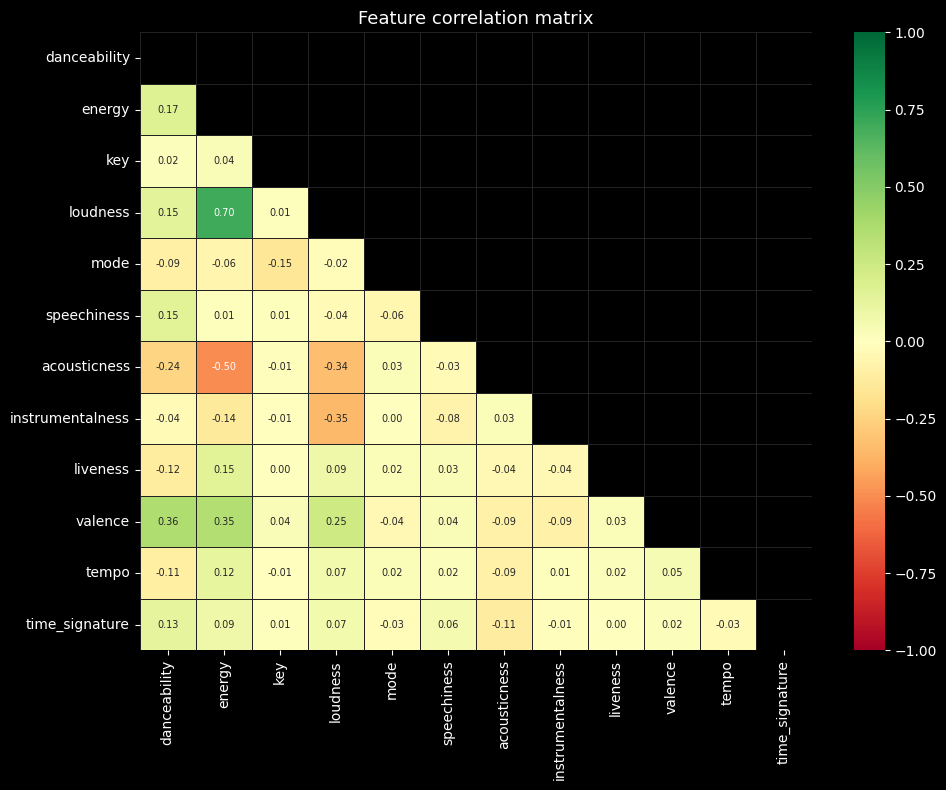

In [21]:
corr = df_all[FEATURES].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor='#222', annot=True, fmt='.2f', annot_kws={'size': 7})
ax.set_title('Feature correlation matrix', color='white', fontsize=13)
plt.tight_layout()
plt.show()

---
## 2. k selection across markets

Each country ran its own silhouette sweep (k = 5–15) and independently chose the best k.

A **high k** means the algorithm needed many clusters to separate the local sound space — a **diverse market** with multiple distinct audio archetypes.  
A **low k** means the local chart sound is more **homogeneous** — a few dominant audio styles cover most of the chart.

72 markets  ·  k 5–15  ·  median 10


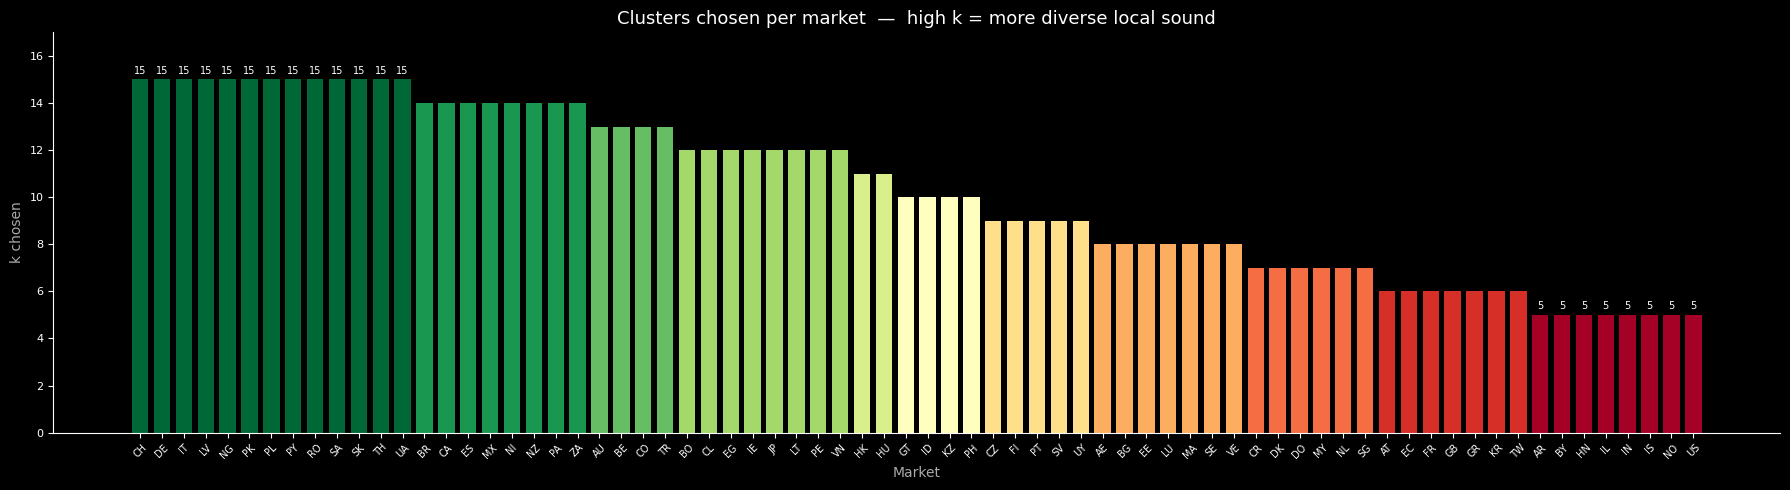

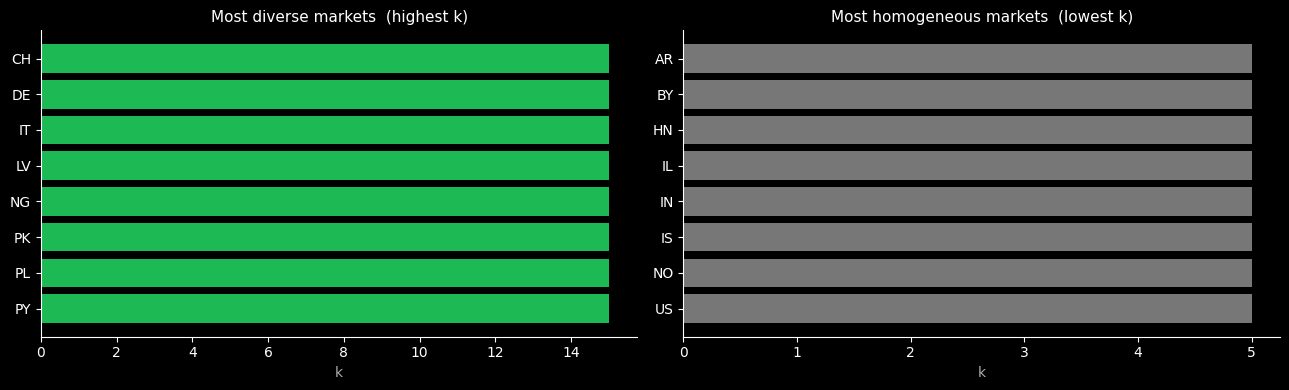

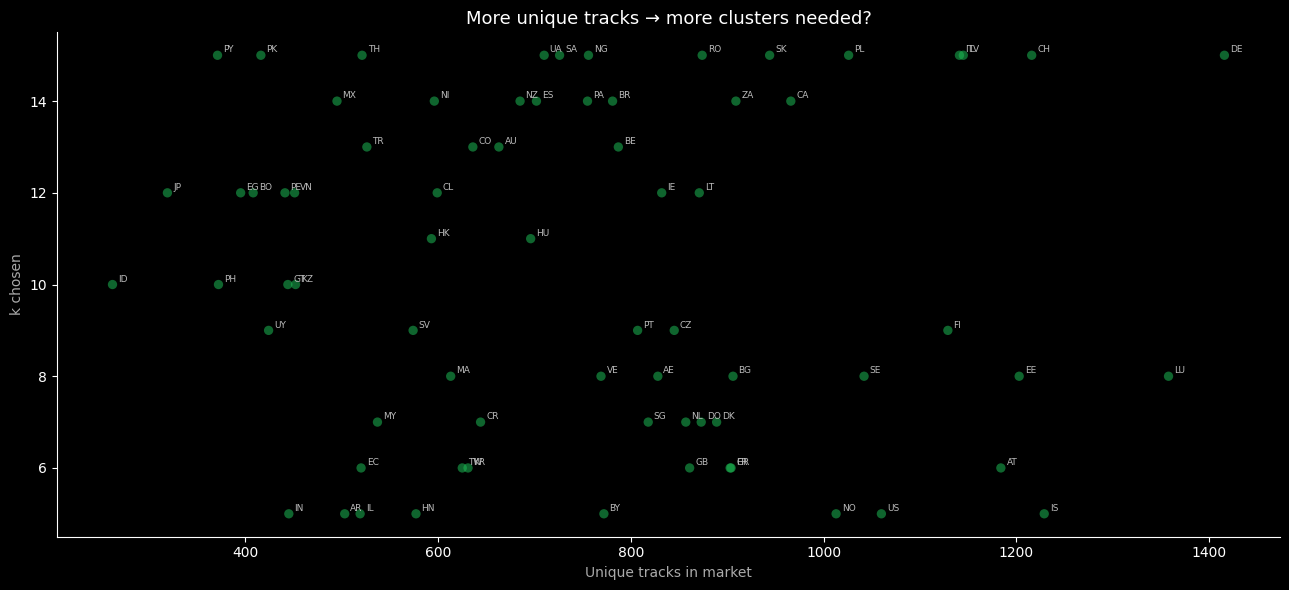

In [32]:
k_df = pd.read_sql("""
    SELECT country,
           max(audio_cluster_id) + 1 AS k,
           count(*)                  AS tracks
    FROM   song_clusters
    WHERE  audio_cluster_id IS NOT NULL AND country <> 'GL'
    GROUP  BY country
    ORDER  BY k DESC, country
""", engine)

if k_df.empty:
    print('No cluster data yet — run Section 0 first.')
else:
    k_min, k_max = k_df.k.min(), k_df.k.max()
    print(f'{len(k_df)} markets  ·  k {k_min}–{k_max}  ·  median {k_df.k.median():.0f}')

    # ── 1. per-country bar chart sorted by k ──────────────────────────────────
    norm_k = [(k - k_min) / (k_max - k_min) for k in k_df.k]
    colors = [plt.cm.RdYlGn(v) for v in norm_k]

    fig, ax = plt.subplots(figsize=(18, 5))
    bars = ax.bar(k_df.country, k_df.k, color=colors, edgecolor='none', width=0.75)

    for bar, row in zip(bars, k_df.itertuples()):
        if row.k in (k_max, k_min):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
                    str(row.k), ha='center', va='bottom', fontsize=7, color='white')

    ax.set_xlabel('Market', color='#aaa', fontsize=10)
    ax.set_ylabel('k chosen', color='#aaa', fontsize=10)
    ax.set_title('Clusters chosen per market  —  high k = more diverse local sound', color='white', fontsize=13)
    ax.tick_params(axis='x', labelsize=7, rotation=45)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_ylim(0, k_max + 2)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

    # ── 2. most vs least diverse ───────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    top = k_df.head(8)
    bot = k_df.tail(8).sort_values('k')

    axes[0].barh(top.country, top.k, color=GREEN, edgecolor='none')
    axes[0].set_title('Most diverse markets  (highest k)', color='white', fontsize=11)
    axes[0].set_xlabel('k', color='#aaa')
    axes[0].invert_yaxis()
    for s in ['top', 'right']: axes[0].spines[s].set_visible(False)

    axes[1].barh(bot.country, bot.k, color='#777', edgecolor='none')
    axes[1].set_title('Most homogeneous markets  (lowest k)', color='white', fontsize=11)
    axes[1].set_xlabel('k', color='#aaa')
    axes[1].invert_yaxis()
    for s in ['top', 'right']: axes[1].spines[s].set_visible(False)

    plt.tight_layout()
    plt.show()

    # ── 3. k vs unique tracks — labelled scatter ──────────────────────────────
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.scatter(k_df.tracks, k_df.k, color=GREEN, alpha=0.55, s=45, edgecolors='none', zorder=2)
    for _, row in k_df.iterrows():
        ax.annotate(row.country, (row.tracks, row.k),
                    textcoords='offset points', xytext=(4, 2),
                    fontsize=6.5, color='#bbb')
    ax.set_xlabel('Unique tracks in market', color='#aaa', fontsize=10)
    ax.set_ylabel('k chosen', color='#aaa', fontsize=10)
    ax.set_title('More unique tracks → more clusters needed?', color='white', fontsize=13)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

    # ── 4. full table with colour gradient ────────────────────────────────────
    k_df.style.background_gradient(subset=['k'], cmap='RdYlGn')


---
## 3. UMAP scatter — pick a country

Change `COUNTRY` to explore any market.

BR: 781 tracks  ·  14 clusters


/var/folders/gz/7_370f5d3bv319qpl0wdkgk40000gp/T/ipykernel_49247/2111609617.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab20', n_c)


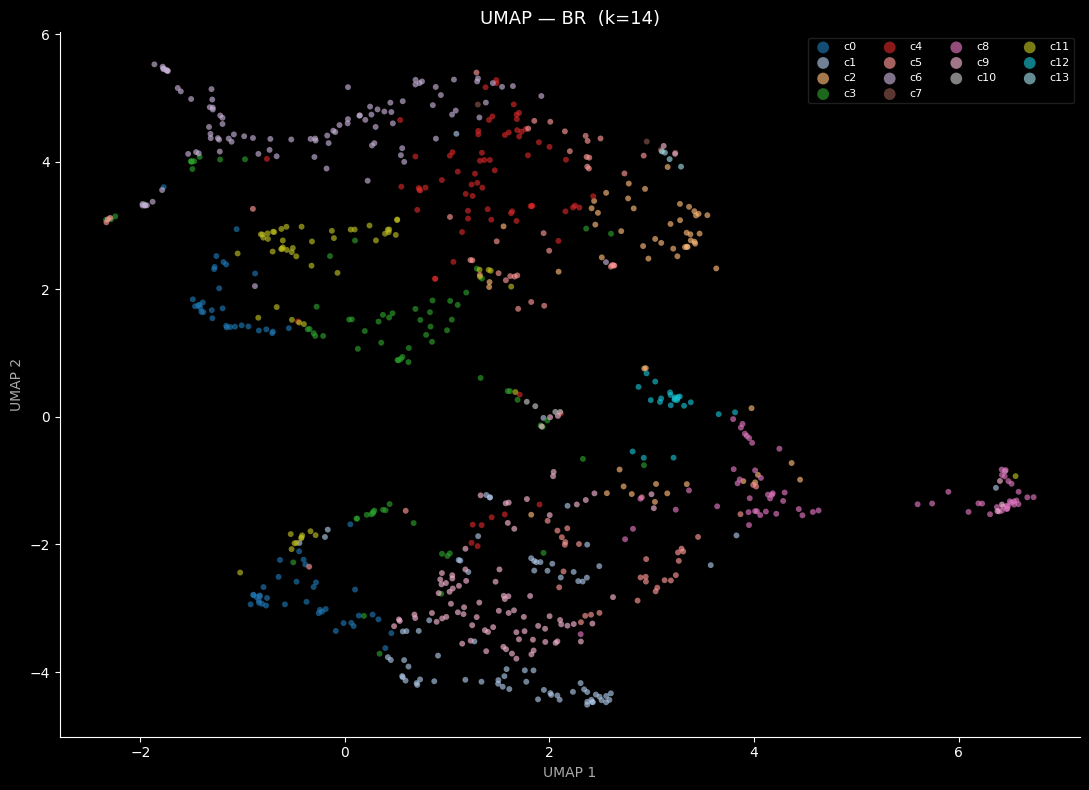

In [ ]:
COUNTRY = 'BR'

df_c = pd.read_sql("""
    SELECT sc.spotify_id, sc.audio_cluster_id, sc.umap_audio_x, sc.umap_audio_y,
           t.name, t.artists
    FROM   song_clusters sc
    JOIN   (SELECT DISTINCT ON (spotify_id) spotify_id, name, artists
            FROM tracks WHERE country = %(c)s) t USING (spotify_id)
    WHERE  sc.country = %(c)s AND sc.audio_cluster_id IS NOT NULL
""", engine, params={'c': COUNTRY})

if df_c.empty:
    print(f'No clusters for {COUNTRY}.')
else:
    n_c = df_c.audio_cluster_id.nunique()
    print(f'{COUNTRY}: {len(df_c):,} tracks  ·  {n_c} clusters')
    palette = plt.cm.get_cmap('tab20', n_c)
    fig, ax = plt.subplots(figsize=(11, 8))
    for cid in sorted(df_c.audio_cluster_id.unique()):
        sub = df_c[df_c.audio_cluster_id == cid]
        ax.scatter(sub.umap_audio_x, sub.umap_audio_y,
                   s=18, alpha=0.65, color=palette(cid), label=f'c{cid}', edgecolors='none')
    ax.set_title(f'UMAP — {COUNTRY}  (k={n_c})', color='white', fontsize=13)
    ax.set_xlabel('UMAP 1', color='#aaa')
    ax.set_ylabel('UMAP 2', color='#aaa')
    ax.legend(markerscale=2, fontsize=8, ncol=4, framealpha=0.15)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.show()

---
## 4. Same track — different markets

A globally popular song often lands in different clusters across countries, reflecting its different *role* in each local soundscape.

In [29]:
# most widely-charted tracks — good candidates
popular = pd.read_sql("""
    SELECT t.spotify_id, t.name, t.artists, count(DISTINCT t.country) AS markets
    FROM   tracks t
    GROUP  BY t.spotify_id, t.name, t.artists
    ORDER  BY markets DESC
    LIMIT  15
""", engine)
popular

,spotify_id,name,artists,markets
0,2plbrEY59IikOBgBGLjaoe,Die With A Smile,"Lady Gaga, Bruno Mars",69
1,4wJ5Qq0jBN4ajy7ouZIV1c,APT.,"ROSÉ, Bruno Mars",67
2,5vNRhkKd0yEAg8suGBpjeY,APT.,"ROSÉ, Bruno Mars",67
3,7so0lgd0zP2Sbgs2d7a1SZ,Die With A Smile,"Lady Gaga, Bruno Mars",67
4,6AI3ezQ4o3HUoP6Dhudph3,Not Like Us,Kendrick Lamar,66
5,2OzhQlSqBEmt7hmkYxfT6m,Fortnight (feat. Post Malone),"Taylor Swift, Post Malone",64
6,0bYg9bo50gSsH3LtXe2SQn,All I Want for Christmas Is You,Mariah Carey,63
7,6dOtVTDdiauQNBQEDOtlAB,BIRDS OF A FEATHER,Billie Eilish,62
8,2qSkIjg1o9h3YT9RAgYN75,Espresso,Sabrina Carpenter,61
9,7gaA3wERFkFkgivjwbSvkG,"yes, and?",Ariana Grande,61


In [25]:
TRACK_ID   = popular.iloc[0].spotify_id   # swap for any id above
TRACK_NAME = popular.iloc[0]['name']

cross = pd.read_sql("""
    SELECT country, audio_cluster_id
    FROM   song_clusters
    WHERE  spotify_id = %(tid)s
      AND  audio_cluster_id IS NOT NULL AND country <> 'GL'
    ORDER  BY country
""", engine, params={'tid': TRACK_ID})

print(f'"{TRACK_NAME}" — {len(cross)} markets  ·  {cross.audio_cluster_id.nunique()} distinct cluster IDs')
cross

"Die With A Smile" — 69 markets  ·  13 distinct cluster IDs


,country,audio_cluster_id
0,AE,0
1,AR,0
2,AT,5
3,AU,9
4,BE,7
...,...,...
64,US,2
65,UY,0
66,VE,6
67,VN,9


---
## 5. Cluster profiles

Average audio features per cluster for the selected country.

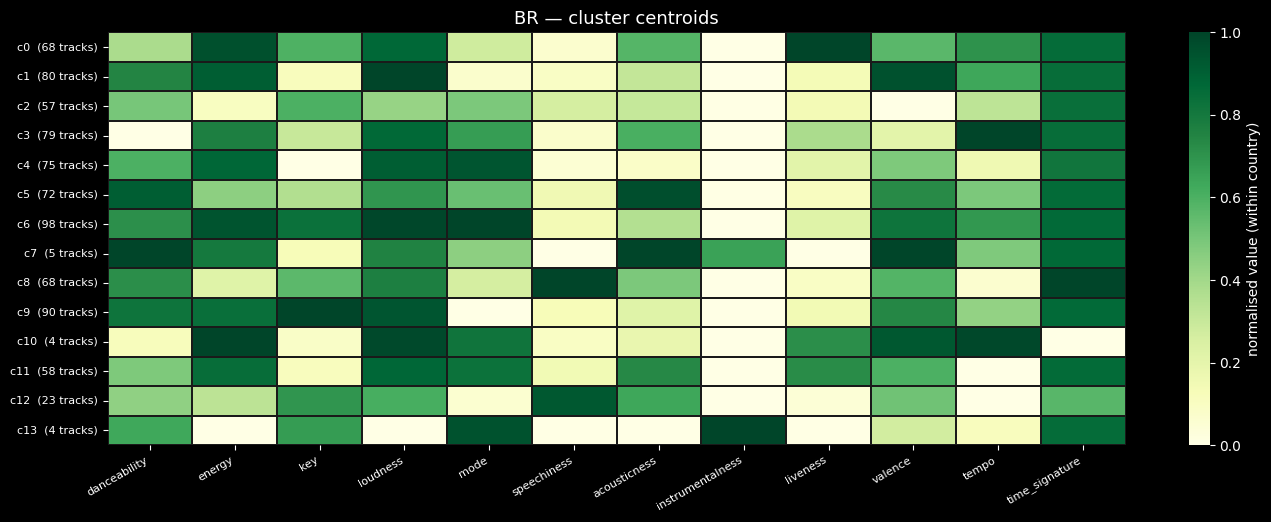

In [30]:
if not df_c.empty:
    feat_avgs = ', '.join(f'AVG(t.{f})::float4 AS {f}' for f in FEATURES)
    profiles  = pd.read_sql(f"""
        SELECT sc.audio_cluster_id, count(DISTINCT t.spotify_id) AS track_count,
               {feat_avgs}
        FROM   song_clusters sc
        JOIN   tracks t ON sc.spotify_id = t.spotify_id AND t.country = %(c)s
        WHERE  sc.country = %(c)s AND sc.audio_cluster_id IS NOT NULL
        GROUP  BY sc.audio_cluster_id
        ORDER  BY sc.audio_cluster_id
    """, engine, params={'c': COUNTRY})

    norm = profiles[FEATURES].copy()
    for col in FEATURES:
        mn, mx = norm[col].min(), norm[col].max()
        norm[col] = (norm[col] - mn) / (mx - mn + 1e-9)

    fig, ax = plt.subplots(figsize=(14, max(5, len(profiles) * 0.38)))
    sns.heatmap(norm.values, ax=ax, xticklabels=FEATURES,
                yticklabels=[f'c{int(r)}  ({int(n)} tracks)'
                             for r, n in zip(profiles.audio_cluster_id, profiles.track_count)],
                cmap='YlGn', linewidths=0.3, linecolor='#1a1a1a',
                cbar_kws={'label': 'normalised value (within country)'})
    ax.set_title(f'{COUNTRY} — cluster centroids', color='white', fontsize=13)
    plt.xticks(rotation=30, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

---
## 6. Sample tracks per cluster

In [31]:
if not df_c.empty:
    samples = pd.read_sql("""
        SELECT sc.audio_cluster_id, t.name, t.artists, count(*) AS appearances
        FROM   song_clusters sc
        JOIN   tracks t ON sc.spotify_id = t.spotify_id AND t.country = %(c)s
        WHERE  sc.country = %(c)s AND sc.audio_cluster_id IS NOT NULL
        GROUP  BY sc.audio_cluster_id, t.name, t.artists
        ORDER  BY sc.audio_cluster_id, appearances DESC
    """, engine, params={'c': COUNTRY})

    pd.set_option('display.max_colwidth', 55)
    (
        samples
        .groupby('audio_cluster_id', group_keys=False)
        .apply(lambda g: g.head(5))
        .reset_index(drop=True)
    )

/var/folders/gz/7_370f5d3bv319qpl0wdkgk40000gp/T/ipykernel_49247/1261130860.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.head(5))
